<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/Walmart_logo_(2008).svg.png" alt="WALMART LOGO" width='30%'/>

# Walmart weekly sales predictor

# 1 - Setup

### A - Imports

In [1]:
# -----------------------------------------------------------------------------
# IMPORTS
# -----------------------------------------------------------------------------

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import seaborn as sns
import plotly.graph_objects as go

# Data prediction
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (r2_score,
                             mean_absolute_error, 
                             mean_squared_error,
                             )

### B - Settings

In [2]:
# -----------------------------------------------------------------------------
# FILE PATH
# -----------------------------------------------------------------------------
file = 'Walmart_Store_sales.csv'


# -----------------------------------------------------------------------------
# COLORS
# -----------------------------------------------------------------------------
palette = ['#4238CA', '#e142d5', '#ff4b9b', 
           '#ffc352', '#f9f871', '#9bde7e', 
           '#4bbc8e', '#039590', '#1c6e7d', '#2f4858', '#5c6684']
direction_dict = {'positive': "#34D399", 'negative': "#FB7373"}

sns.set_theme(style='darkgrid', palette=palette)
formatter = StrMethodFormatter('{x:,.0f}') # Avoid scientific notations in matplotlib/seaborn
# pd.options.display.float_format = '{:,.4f}'.format # Avoid scientific notations in pandas dataframes

### C - Functions definitions

In [3]:
# -----------------------------------------------------------------------------
# READ FILE
# -----------------------------------------------------------------------------
def read_file_safe(file_path) -> pd.DataFrame:
    '''Try several encoding to read a CSV file'''
    encodings = ['utf-16', 'utf-8', 'latin1']                           # Try several encodings in case of error
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f'✓ Successfully read with {encoding}')
            print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns')   
            print(f'Columns: {list(df.columns)}') 
            return df
        except FileNotFoundError:
            raise FileNotFoundError(f"File '{file_path}' not found.")   # Return an error if file is not found


        except UnicodeDecodeError:                                      # Return an error if loading fails
            print(f'Failed with {encoding}')
            continue                                                    # Load next encoding if there's still left
    raise ValueError(f'Could not read {file_path} with any encoding')   # Return ValueError if all encodings failed


# -----------------------------------------------------------------------------
# NORMALIZE COLUMNS NAMES
# -----------------------------------------------------------------------------
def normalize_cols(df):
    '''Normalize columns name: lower char, remove spaces/special chars'''
    df.columns = (
        df.columns.str.lower()
                    .str.replace(r'[^a-z0-9]+', '_', regex=True) # 1 or more (+) chars that are not (^) a-z or 0-9
                    .str.strip('_')
    )
    return df


# -----------------------------------------------------------------------------
# SCORES & METRICS
# -----------------------------------------------------------------------------
def ml_metrics(y_train_true, y_train_pred, y_test_true, y_test_pred, model):
    '''Build metrics from model predictions'''
    # train
    r2_train = r2_score(y_train_true, y_train_pred)
    mae_train = mean_absolute_error(y_train_true, y_train_pred)
    rmse_train = mean_squared_error(y_train_true, y_train_pred) ** 0.5   # sqrt of MSE = RMSE
    
    # test
    r2_test = r2_score(y_test_true, y_test_pred)
    mae_test = mean_absolute_error(y_test_true, y_test_pred)
    rmse_test = mean_squared_error(y_test_true, y_test_pred) ** 0.5   # sqrt of MSE = RMSE

    # result
    return pd.DataFrame({
        'model': model,
        'set':  ['train', 
                 'test'],
        'R2':   [r2_train, 
                 r2_test],
        'MAE':  [mae_train, 
                 mae_test],
        'RMSE': [rmse_train, 
                 rmse_test],
        })

### D - Data loading

In [4]:
# -----------------------------------------------------------------------------
# LOAD AND READDATA FROM FILE
# -----------------------------------------------------------------------------
print('\n' + '-'*80)
print('PART 1: LOADING DATASETS')
print('-'*80)
print()


walmart_df = read_file_safe(file)
walmart_df = normalize_cols(walmart_df)
walmart_df['date'] = pd.to_datetime(walmart_df['date'], format='%d-%m-%Y')


--------------------------------------------------------------------------------
PART 1: LOADING DATASETS
--------------------------------------------------------------------------------

Failed with utf-16
✓ Successfully read with utf-8
Loaded 150 rows, 8 columns
Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


# 2 - Explanatory data analysis and data preprocessing

### A - First look

In [5]:
# -----------------------------------------------------------------------------
# CHECK FOR DUPLICATED DATA
# -----------------------------------------------------------------------------
print('\n' + '-'*80)
print('QUICK ANALYSIS')
print('-'*80)
print()

print('Duplicated lines: ')
print(f'There are {walmart_df.duplicated().sum()} duplicated lines')


# -----------------------------------------------------------------------------
# DATA ANALYSIS: SHAPE
# -----------------------------------------------------------------------------
print()
print('Shape: ')
print(f"There's {walmart_df.shape[0]} rows and {walmart_df.shape[1]} columns")
print()


# -----------------------------------------------------------------------------
# DATA ANALYSIS: HEAD ON ALL COLUMNS
# -----------------------------------------------------------------------------
print()
print('Dataset Preview: ')
pd.set_option('display.max_columns', None)
display(walmart_df.head())


# -----------------------------------------------------------------------------
# DATA ANALYSIS: DESCRIBE ON ALL COLUMNS
# -----------------------------------------------------------------------------
print()
print('Dataset Statistics: ')
display(walmart_df.describe(include='all'))
pd.reset_option('display.max_columns')


--------------------------------------------------------------------------------
QUICK ANALYSIS
--------------------------------------------------------------------------------

Duplicated lines: 
There are 0 duplicated lines

Shape: 
There's 150 rows and 8 columns


Dataset Preview: 


,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,2011-03-25,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,2012-07-27,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaT,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,2010-05-28,1644470.66,0.0,78.89,2.759,212.412888,7.092



Dataset Statistics: 


,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,2011-05-07 09:05:27.272727,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
min,1.000000,2010-02-05 00:00:00,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,2010-08-16 12:00:00,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,2011-05-09 12:00:00,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,2012-01-14 18:00:00,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2012-10-19 00:00:00,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173


The raw file has `150 rows` and `8 columns`: a very small dataset for a regression task.

### B - Missing data and types

In [6]:
# -----------------------------------------------------------------------------
# DATASET
# -----------------------------------------------------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print('\n' + '-'*80)
print('MISSING DATA AND TYPES')
print('-'*80)
missing_values_pct =  (100 * walmart_df.isna().sum() / walmart_df.shape[0]).round(2)            # Get all missing data percentage
missing_values_df = missing_values_pct.sort_values(ascending=False).to_frame(name='missing_%')  # Create a dataframe from the serie
dtype_df = walmart_df.dtypes.to_frame(name='dtype')                                             # Dataframe of type value

infotypes_df = missing_values_df.merge(dtype_df, left_index=True, right_index=True)             # Merge both dataframe to get all result
display(infotypes_df)

# Reset display options
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')


--------------------------------------------------------------------------------
MISSING DATA AND TYPES
--------------------------------------------------------------------------------


,missing_%,dtype
date,12.00,datetime64[us]
temperature,12.00,float64
unemployment,10.00,float64
weekly_sales,9.33,float64
fuel_price,9.33,float64
holiday_flag,8.00,float64
cpi,8.00,float64
store,0.00,float64


In [7]:
# -----------------------------------------------------------------------------
# DROPPING MISSING VALUES
# -----------------------------------------------------------------------------

# Droping missing target
target_missing = walmart_df['weekly_sales'].isna().sum()
walmart_df.dropna(subset='weekly_sales', inplace=True)
print(f'Rows dropped from missing target: {target_missing} | Rows for modelling: {len(walmart_df)}')

# Droping missing dates
date_missing = walmart_df['date'].isna().sum()
walmart_df.dropna(subset='date', inplace=True)
print(f'Rows dropped from missing date: {date_missing} | Rows for modelling: {len(walmart_df)}')

Rows dropped from missing target: 14 | Rows for modelling: 136
Rows dropped from missing date: 18 | Rows for modelling: 118


### C - Features creation

In [8]:
# -----------------------------------------------------------------------------
# CREATE FEATURES
# -----------------------------------------------------------------------------

# Year
walmart_df['year'] = walmart_df['date'].dt.year.astype('Int16')

# Month
walmart_df['month'] = walmart_df['date'].dt.month.astype('Int8')

# Day
walmart_df['day'] = walmart_df['date'].dt.day.astype('Int8')

# Day of week
walmart_df['day_of_week'] = walmart_df['date'].dt.dayofweek.astype('Int8')

# Results
date_markers = ['year', 'month', 'day', 'day_of_week']

for date_marker in date_markers:
    print(f'{date_marker}:')
    display(walmart_df[date_marker].value_counts().sort_index())

year:


year
2010    51
2011    37
2012    30
Name: count, dtype: Int64

month:


month
1      5
2     12
3     10
4      9
5     14
6     14
7     12
8     11
9      7
10     8
11     8
12     8
Name: count, dtype: Int64

day:


day
1      2
2      4
3      2
4      2
5      2
6      5
7      4
8      1
9      2
10     7
11     3
12    11
13     3
14     2
15     3
16     6
17     4
18     6
19     7
20     5
22     4
23     2
24     3
25     7
26     5
27     5
28     3
29     1
30     6
31     1
Name: count, dtype: Int64

day_of_week:


day_of_week
4    118
Name: count, dtype: Int64

After computing the day of the week for each valid date, we found that all observations correspond to **Friday** (`day = 4`).

Since this feature has the same value for every observation, it does not provide any useful information for the analysis and for the ML. Therefore, we will drop the `day_of_week` column.


In [9]:
# -----------------------------------------------------------------------------
# DROPPING DAY OF WEEK
# -----------------------------------------------------------------------------
walmart_df.drop(columns='day_of_week', inplace=True)

# -----------------------------------------------------------------------------
# DROPPING INVALID VALUES AND OUTLIERS
# -----------------------------------------------------------------------------
cols = ['temperature', 'fuel_price', 'cpi', 'unemployment']

for col in cols:
    mean = walmart_df[col].mean()
    std = walmart_df[col].std()
    lower, upper = mean - 3*std, mean + 3*std
    # walmart_df = walmart_df[(walmart_df[col] >= lower) & (walmart_df[col] <= upper)]
    mask = walmart_df[col].isna() | walmart_df[col].between(lower, upper)
    walmart_df = walmart_df[mask]

### D - Weekly sales over time

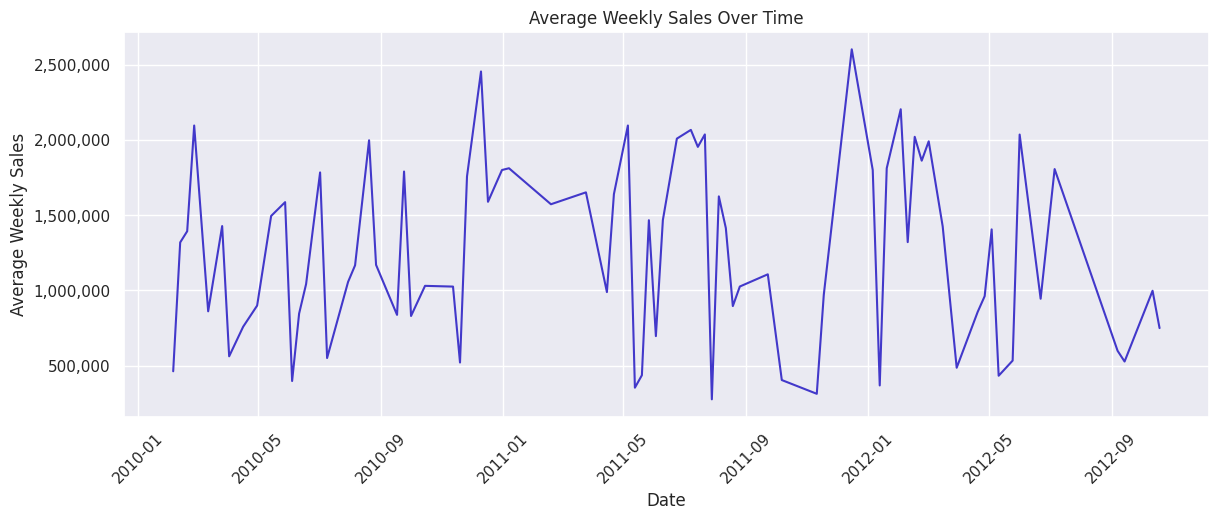

In [10]:
# -----------------------------------------------------------------------------
# WEEKLY SALES OVER TIME
# -----------------------------------------------------------------------------

sales_by_date = (
    walmart_df
    .groupby("date")["weekly_sales"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14,5))

ax.plot(
    sales_by_date["date"],
    sales_by_date["weekly_sales"]
)

plt.title("Average Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Average Weekly Sales")
ax.yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45)

plt.show()

### E - Weekly sales over time

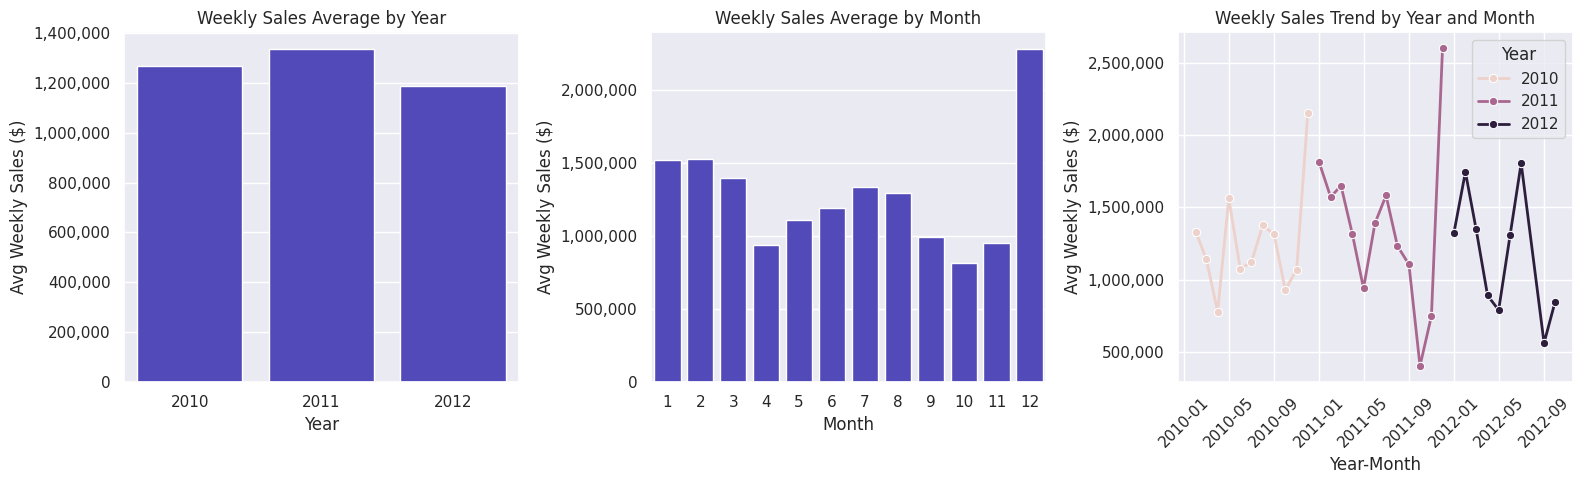

In [11]:
# -----------------------------------------------------------------------------
# SEASONALITY - AVERAGE WEEKLY SALES BY MONTH AND BY YEAR-MONTH
# -----------------------------------------------------------------------------
year_df = walmart_df.dropna(subset=['year'])
month_df = walmart_df.dropna(subset=['month'])

# Build year-month for the lineplot
ym_df = walmart_df.dropna(subset=['date', 'weekly_sales']).copy()
ym_df['Date'] = pd.to_datetime(ym_df['date'], format='%d-%m-%Y')
ym_df['year_month'] = ym_df['date'].dt.to_period('M').dt.to_timestamp()

ym_series = (
    ym_df
    .groupby(['year', 'year_month'])['weekly_sales']
    .mean()
    .reset_index()
)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Average by year (barplot)
sns.barplot(data=year_df, 
            x='year', 
            y='weekly_sales',
            color=palette[0], 
            ax=axes[0], 
            errorbar=None)

axes[0].set_title('Weekly Sales Average by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].yaxis.set_major_formatter(formatter)


# Center: Average Weekly Sales by Month (barplot)
sns.barplot(data=month_df, 
            x='month', 
            y='weekly_sales',
            color=palette[0], 
            ax=axes[1], 
            errorbar=None)

axes[1].set_title('Weekly Sales Average by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Weekly Sales ($)')
axes[1].yaxis.set_major_formatter(formatter)

# Right: Weekly Sales Trend by Year-Month (lineplot)
sns.lineplot(data=ym_series, 
             x='year_month', 
             y='weekly_sales',
             hue='year',           # Color by year
             marker='o', 
             linewidth=2, 
             ax=axes[2])
axes[2].set_title('Weekly Sales Trend by Year and Month')
axes[2].set_xlabel('Year-Month')
axes[2].set_ylabel('Avg Weekly Sales ($)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Year', loc='best')
axes[2].yaxis.set_major_formatter(formatter)

plt.tight_layout()  # Adjust spacing
plt.show()

### F - Weekly sales distribution

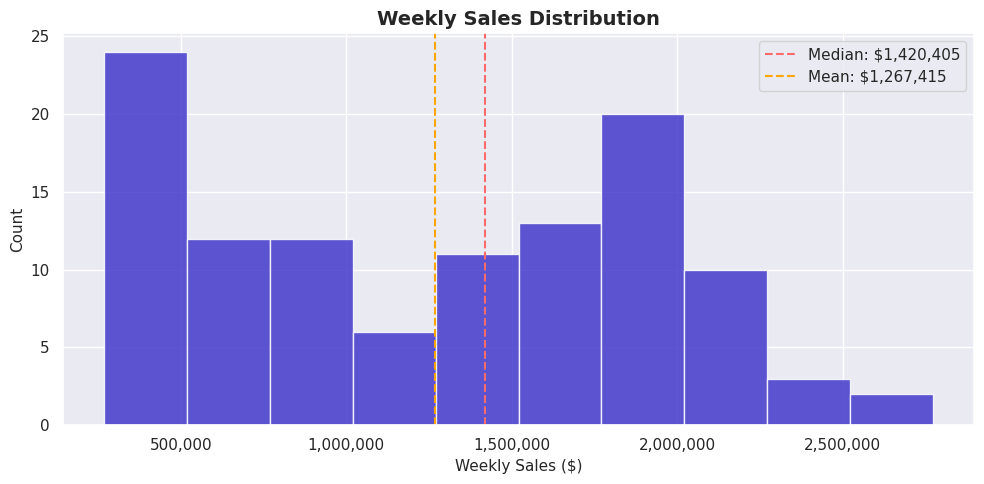

Weekly max: 2,771,397.17
Weekly min: 268,929.03


In [12]:
# -----------------------------------------------------------------------------
# WEEKLY SALES DISTRIBUTION
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

sales_valid = walmart_df["weekly_sales"].dropna()

ax.hist(sales_valid, 
        bins=10, 
        color="#4238CA", 
        edgecolor="white", 
        alpha=0.85
        )

ax.axvline(sales_valid.median(), color='#ff6b6b', linestyle='--', linewidth=1.5,
           label=f'Median: ${sales_valid.median():,.0f}')
ax.axvline(sales_valid.mean(), color='#ffa502', linestyle='--', linewidth=1.5,
           label=f'Mean: ${sales_valid.mean():,.0f}')

ax.set_title('Weekly Sales Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Weekly Sales ($)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.xaxis.set_major_formatter(formatter)

ax.legend()

plt.tight_layout()
plt.show()

print(f'Weekly max: {sales_valid.max():,.2f}')
print(f'Weekly min: {sales_valid.min():,.2f}')

### G - Weekly sales vs holiday

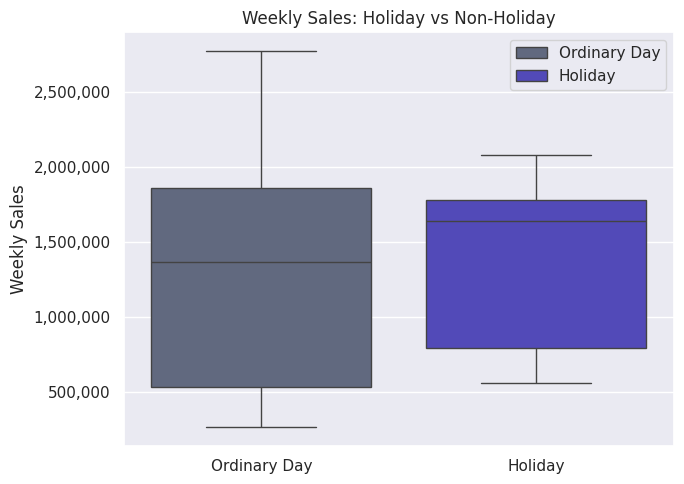

There's 7 holiday rows in the dataframe:
Holiday median: 1,641,957.44
Ordinary day median: 1,366,395.96

Holiday min: 563,460.77
Ordinary day min: 268,929.03


In [13]:
# -----------------------------------------------------------------------------
# WEEKLY SALES vs HOLIDAYS
# -----------------------------------------------------------------------------
holiday_df = walmart_df.copy()
holiday_df['holiday_flag'] = holiday_df['holiday_flag'].astype('Int64').map({0: 'Ordinary Day', 1: 'Holiday'})


plt.figure(figsize=(7,5))

ax = sns.boxplot(
    data=holiday_df,
    x='holiday_flag',
    y='weekly_sales',
    hue='holiday_flag',
    palette=[palette[10], palette[0]]
)

ax.set_title('Weekly Sales: Holiday vs Non-Holiday')
ax.set_xlabel('')
ax.set_ylabel('Weekly Sales')

ax.yaxis.set_major_formatter(formatter)
ax.legend(title=None)

plt.tight_layout()
plt.show()


print(f"There's {len(holiday_df[holiday_df['holiday_flag'] == 'Holiday'])} holiday rows in the dataframe:")
print(f'Holiday median: {holiday_df[holiday_df['holiday_flag'] == 'Holiday']['weekly_sales'].median():,.2f}')
print(f'Ordinary day median: {holiday_df[holiday_df['holiday_flag'] == 'Ordinary Day']['weekly_sales'].median():,.2f}')
print()
print(f'Holiday min: {holiday_df[holiday_df['holiday_flag'] == 'Holiday']['weekly_sales'].min():,.2f}')
print(f'Ordinary day min: {holiday_df[holiday_df['holiday_flag'] == 'Ordinary Day']['weekly_sales'].min():,.2f}')

### H - Weekly sales vs economic indicators

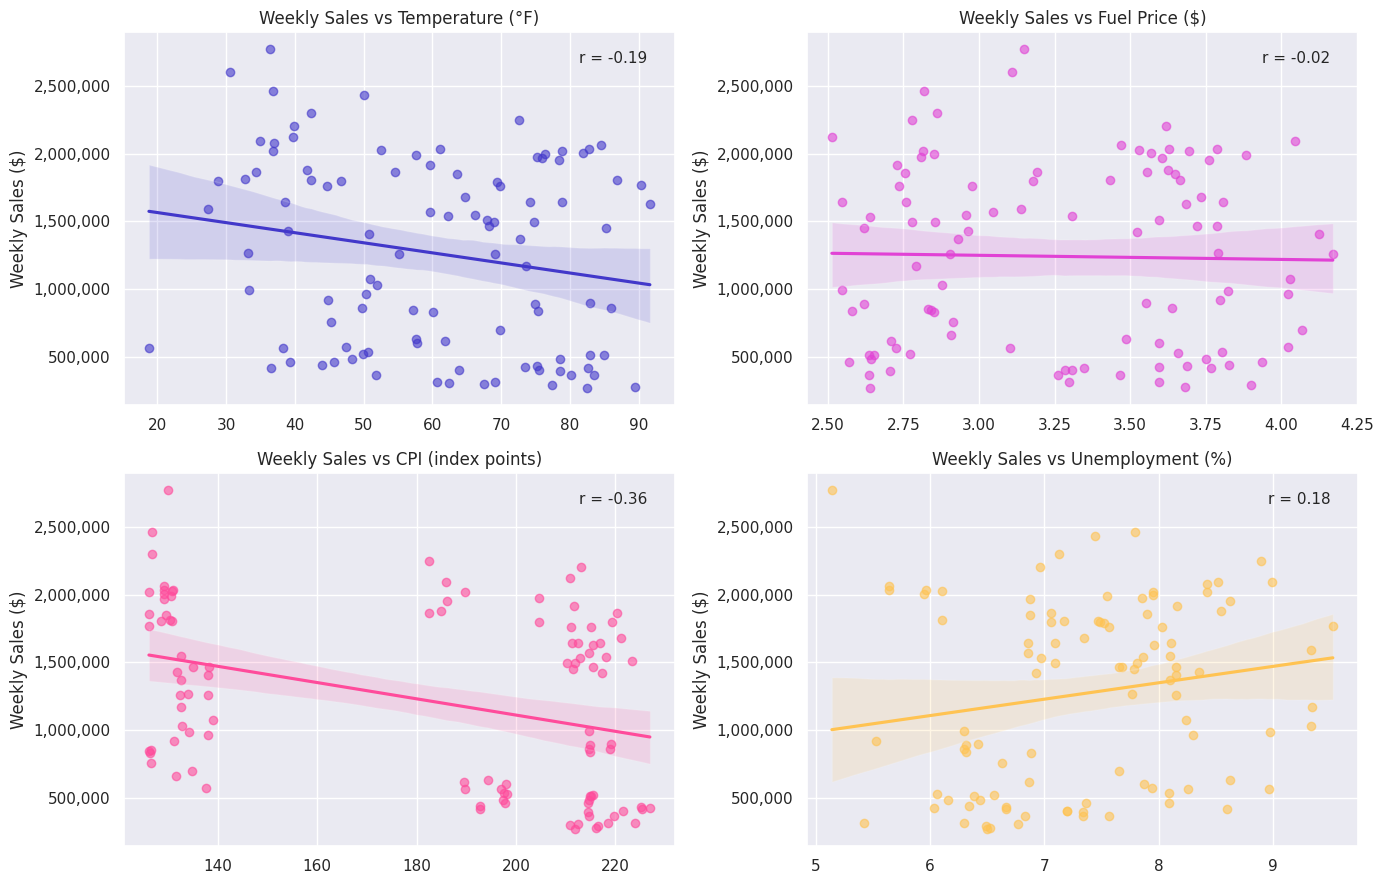

In [14]:
# -----------------------------------------------------------------------------
# WEEKLY SALES vs ECONOMIC INDICATORS
# -----------------------------------------------------------------------------
economic_cols = ['temperature', 'fuel_price', 'cpi', 'unemployment']
economic_cols_display = ['Temperature', 'Fuel Price', 'CPI', 'Unemployment']
units = ['(°F)', '($)', '(index points)', '(%)']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col, displ, unit, color, in zip(axes.flat, economic_cols, economic_cols_display, units, palette):
    sns.regplot(data=walmart_df, 
                x=col, 
                y='weekly_sales', 
                ax=ax,
                color=color, 
                scatter_kws={'alpha': 0.6}
                )
    
    # Compute correlation
    r = walmart_df['weekly_sales'].corr(walmart_df[col])
    ax.text(0.95, 
            0.95, 
            f'r = {r:.2f}',
            transform=ax.transAxes,
            ha='right', 
            va='top',
            fontsize=11
            )

    ax.set_title(f'Weekly Sales vs {displ} {unit}')
    ax.set_xlabel('')
    ax.set_ylabel(f'Weekly Sales ($)')
    ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### I - Store Gap

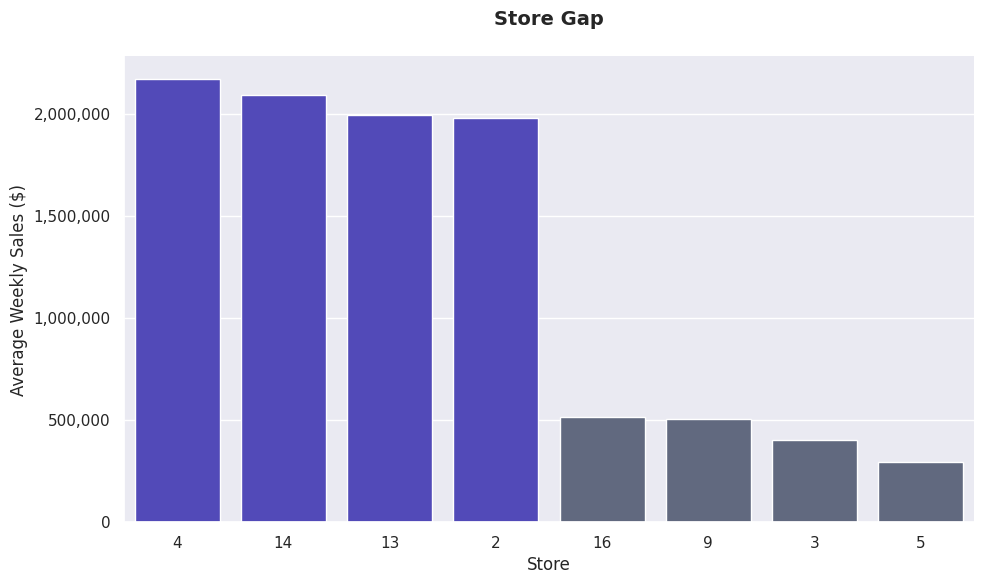

Store 4 leads: $2,173,759 per week on average
Store 5 trails: $294,399 per week on average
Gap: 7.4x spread between stores


In [15]:
# -----------------------------------------------------------------------------
# STORE GAP
# -----------------------------------------------------------------------------
N_TOP = 4
N_BOTTOM = 4

store_avg = (
    walmart_df.groupby('store')['weekly_sales']
    .mean()
    .sort_values(ascending=False)
)

top_stores = store_avg.head(N_TOP)
bottom_stores = store_avg.tail(N_BOTTOM)
store_gap_df = pd.concat([top_stores, bottom_stores]).reset_index()
store_gap_df.columns = ['store', 'avg_weekly_sales']

store_gap_df['ranking'] = ['top'] * N_TOP + ['bottom'] * N_BOTTOM
store_gap_df['store'] = store_gap_df['store'].astype(int).astype(str)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=store_gap_df,
    x='store',
    y='avg_weekly_sales',
    hue='ranking',
    palette={'top': "#4238CA", 'bottom': "#5c6684"},
    order=store_gap_df['store'],
    alpha=1,
)


plt.title('Store Gap', fontsize=14, fontweight='bold', y=1.05)
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales ($)')
ax.yaxis.set_major_formatter(formatter)
ax.get_legend().remove()

sns.despine()
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# STORE GAP SUMMARY
# -----------------------------------------------------------------------------
best_idx = store_gap_df['avg_weekly_sales'].idxmax()
last_idx = store_gap_df['avg_weekly_sales'].idxmin()

best_store, best_val = store_gap_df.loc[best_idx, ['store', 'avg_weekly_sales']]
last_store, last_val = store_gap_df.loc[last_idx, ['store', 'avg_weekly_sales']]

gap_ratio = best_val / last_val

print(f'Store {best_store} leads: ${best_val:,.0f} per week on average')
print(f'Store {last_store} trails: ${last_val:,.0f} per week on average')
print(f'Gap: {gap_ratio:.1f}x spread between stores')

### J - Correlation matrix

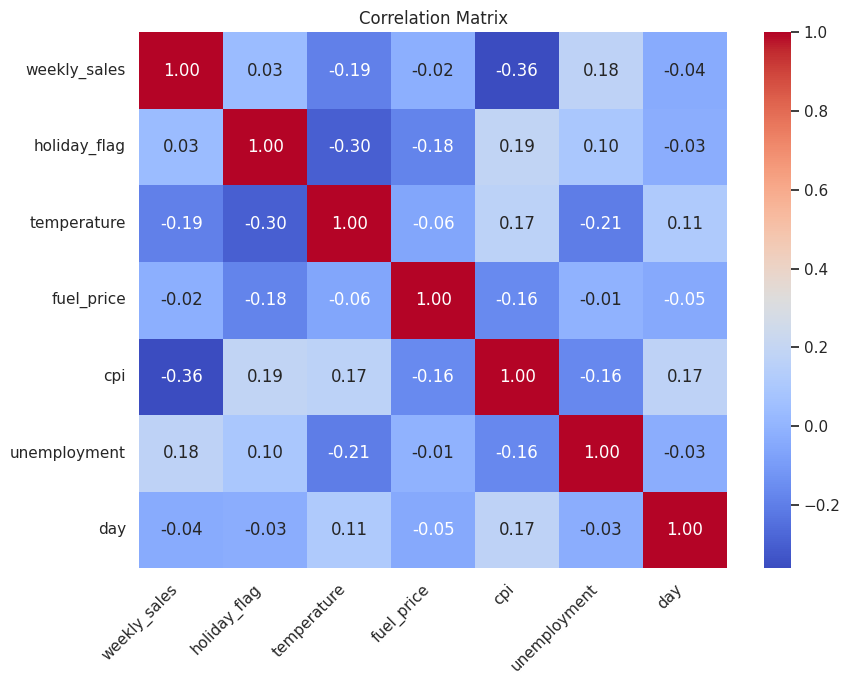

In [16]:
# -----------------------------------------------------------------------------
# CORRELATION MATRIX
# -----------------------------------------------------------------------------


plt.figure(figsize=(9, 7))

corr = walmart_df.drop(columns=['store', 'year', 'month']).corr(numeric_only=True) # Store type is int but it's just a category

ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

ax.set_title("Correlation Matrix")
plt.xticks(rotation=45,
           ha='right'
           )

plt.tight_layout()
plt.show()

# 3 - Baseline model: linear regression

## 3.1 - Settings

In [17]:
# -----------------------------------------------------------------------------
# STORE ID CONVERSION FOR ML MODEL
# -----------------------------------------------------------------------------
# Converting store to str since we don't want it to be considered a numerical value for the ML modeling
walmart_df['store'] = walmart_df['store'].astype('int').astype('str')

# Converting holiday_flag to str for imputation
walmart_df['holiday_flag'] = walmart_df['holiday_flag'].map({0.0: '0', 1.0: '1'})

# Converting to str year, month and day so they are treated as categorical values
# Year
walmart_df['year'] = walmart_df['year'].astype('str')
# Month
walmart_df['month'] = walmart_df['month'].astype('str')
# Droppping day: No useful information and overfitting
# walmart_df['day'] = walmart_df['day'].astype('str')
walmart_df.drop(columns='day', inplace=True)

# Droping date
walmart_df.drop(columns='date', inplace=True)

print(f'The dataset has a total of {walmart_df.shape[0]} rows for the ML training and testing')


# -----------------------------------------------------------------------------
# TARGET AND FEATURES
# -----------------------------------------------------------------------------
# Separate target variable Y from features X
print("Separating labels from features...")

features_list = ['store', 'holiday_flag', 'temperature',
                'fuel_price', 'cpi', 'unemployment', 
                'year', 'month']

target_variable = 'weekly_sales'


# -----------------------------------------------------------------------------
# TRAIN TEST SPLIT
# -----------------------------------------------------------------------------

X = walmart_df.loc[:,features_list]
Y = walmart_df.loc[:,target_variable]

print("...Done.")
print()

print('Y : ')
print(Y.head())
print()
print('X :')
print(X.head())


print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=0)
print("...Done.")
print()


# -----------------------------------------------------------------------------
# SEPARATING NUMERIC AND CATEGORICAL VARIABLES
# -----------------------------------------------------------------------------
# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []
for column, dtype in X.dtypes.items():
    dtype_str = str(dtype).lower()
    if ('float' in dtype_str) or ('int' in dtype_str) :
        numeric_features.append(column)
    else :
        categorical_features.append(column)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

The dataset has a total of 113 rows for the ML training and testing
Separating labels from features...
...Done.

Y : 
0    1572117.54
1    1807545.43
4    1644470.66
5    1857533.70
6     695396.19
Name: weekly_sales, dtype: float64

X :
  store holiday_flag  temperature  fuel_price         cpi  unemployment  year  \
0     6          NaN        59.61       3.045  214.777523         6.858  2011   
1    13            0        42.38       3.435  128.616064         7.470  2011   
4     6            0        78.89       2.759  212.412888         7.092  2010   
5     4            0          NaN       2.756  126.160226         7.896  2010   
6    15            0        69.80       4.069  134.855161         7.658  2011   

  month  
0     2  
1     3  
4     5  
5     5  
6     6  
Dividing into train and test sets...
...Done.

Found numeric features  ['temperature', 'fuel_price', 'cpi', 'unemployment']
Found categorical features  ['store', 'holiday_flag', 'year', 'month']


**We removed day because:**

* All the data is from **Fridays**, so the day of the week didn't matter (we already dropped it for that reason).
* The day value only showed "which Friday of the month": it **didn't give useful information**
* When turned into separate categories, it created about **31 groups** from just 90 training rows
* This made the models memorize the training data too closely (**overfitting**) and perform worse
* Removing it helped the models work better on new data

## 3.2 - Linear regression

In [18]:
# -----------------------------------------------------------------------------
# PIPELINE
# -----------------------------------------------------------------------------
# Create pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # missing values will be replaced by columns' mean
    ('scaler', StandardScaler())
])

# Create pipeline for categorical features
# handle_unknown: if error, the encoder silently maps that unknown category to all zeros across the dummy columns for that feature
categorical_transformer = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # missing values will be replaced by the most common value
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) 
    ])



# Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Preprocessings on train set
print("Performing preprocessings on train set...")
print(X_train.head()) # type: ignore
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5,:]) # type: ignore
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test) # Don't fit again !!
print('...Done.')
print(X_test[0:5,:]) # type: ignore
print()


# -----------------------------------------------------------------------------
# TRAINING
# -----------------------------------------------------------------------------
# Train model
model = LinearRegression()

print("Training model...")
model.fit(X_train, Y_train) # Training is always done on train set !!
print("...Done.")
print()

# -----------------------------------------------------------------------------
# PREDICTIONS
# -----------------------------------------------------------------------------
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = model.predict(X_train)
print("...Done.")
print(Y_train_pred[0:5])
print()

# Predictions on test set
print("Predictions on test set...")
Y_test_pred = model.predict(X_test)
print("...Done.")
print(Y_test_pred[0:5])
print()



# -----------------------------------------------------------------------------
# METRICS EXPORT
# -----------------------------------------------------------------------------
# Print R^2 scores
print("R2 score on training set : ", r2_score(Y_train, Y_train_pred))
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))


result_lr = ml_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred, 'LR')

Performing preprocessings on train set...
    store holiday_flag  temperature  fuel_price         cpi  unemployment  \
52      9            0        85.02       2.653  214.896576           NaN   
11     18            0        52.02       2.878  132.763355         9.331   
105    19            0        72.83       2.932  132.598387         8.099   
110    20            1        28.85       3.179  204.643227         7.484   
75     20            0        75.17       2.808  204.567546         7.856   

     year month  
52   2010     6  
11   2010    10  
105  2010     7  
110  2010    12  
75   2010     6  
...Done.
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31 stored elements and shape (5, 36)>
  Coords	Values
  (0, 0)	1.528249450013191
  (0, 1)	-1.3674775902898229
  (0, 2)	0.9862814513028467
  (0, 3)	-9.673304082775928e-16
  (0, 21)	1.0
  (0, 32)	1.0
  (1, 0)	-0.41637335122891744
  (1, 1)	-0.8775279711454447
  (1, 2)	-1.158556659235
  (1, 3)	2.0860897382534676
  (1, 

## 3.3 - Features importance

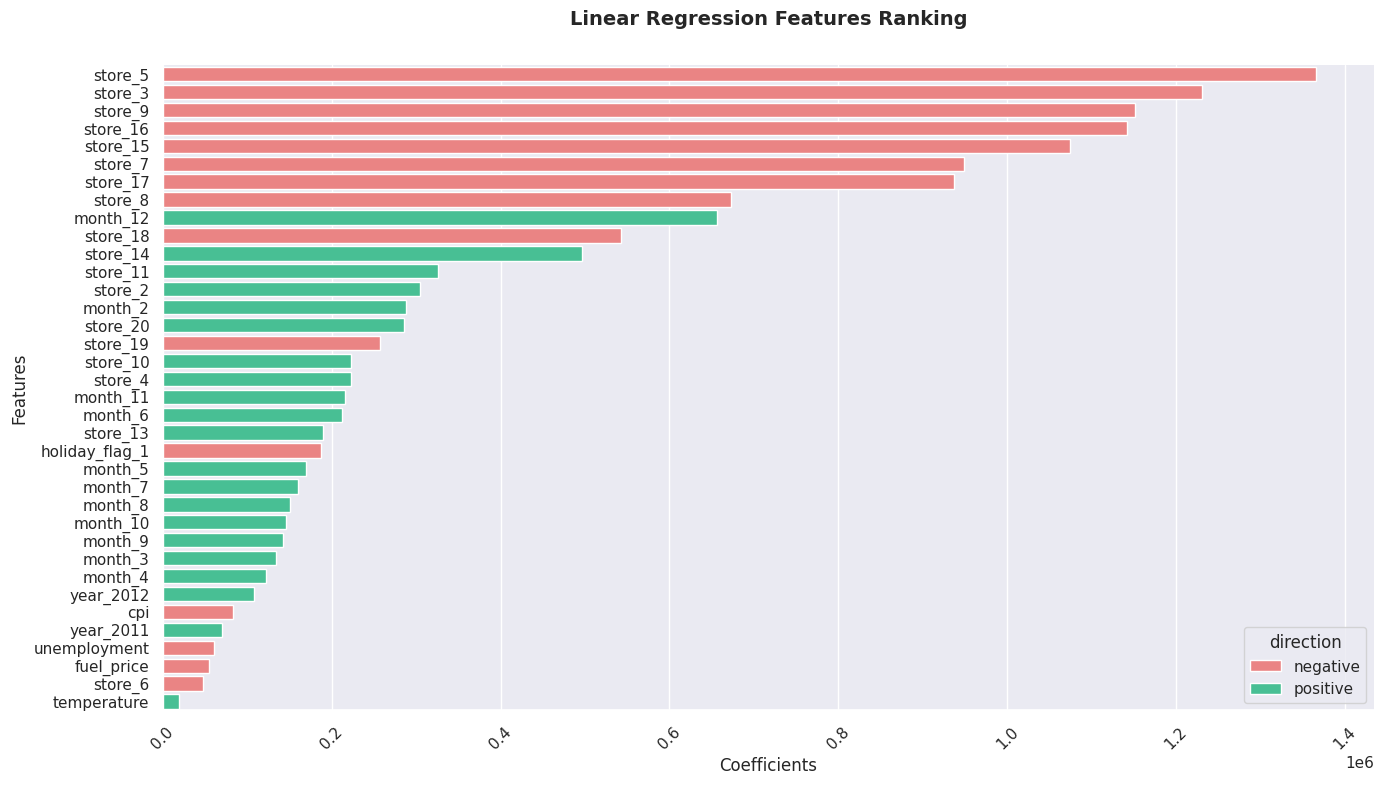

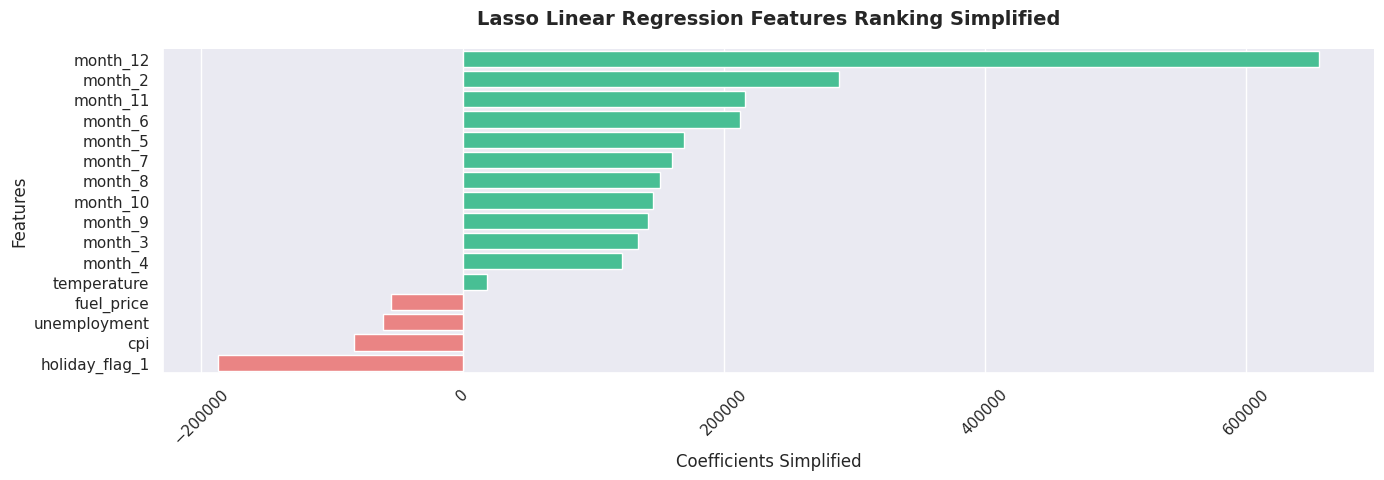

In [19]:
# -----------------------------------------------------------------------------
# LINEAR REGRESSION FEATURES IMPORTANCE
# -----------------------------------------------------------------------------
coef_lr_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False).reset_index(drop=True)

# For readability
coef_lr_df['feature'] = coef_lr_df['feature'].str.replace('cat__', '').str.replace('num__', '')
coef_lr_df['direction'] = coef_lr_df['coefficient'].map(lambda x: 'positive' if x >= 0 else 'negative')
coef_lr_simplified_df = coef_lr_df.copy() # For simplified version
coef_lr_df['coefficient'] = coef_lr_df['coefficient'].abs()

coef_lr_df = coef_lr_df.sort_values('coefficient', ascending=False).reset_index(drop=True)

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=coef_lr_df, 
            x='coefficient',
            y='feature',
            hue='direction',
            palette=direction_dict, 
            alpha=1,
)

plt.title(f'Linear Regression Features Ranking', fontsize=14, fontweight='bold', y=1.05)
plt.ylabel('Features')
plt.xlabel('Coefficients')
plt.xticks(rotation=45)

sns.despine()       # Remove borders for cleaner look
plt.tight_layout()  # Adjust spacing
plt.show()



# -----------------------------------------------------------------------------
# LINEAR REGRESSION FEATURES IMPORTANCE SIMPLIFIED
# -----------------------------------------------------------------------------
feature_list = ['month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 
                'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 
                'unemployment', 'fuel_price', 'temperature', 'cpi', 'year', 'holiday_flag_1']
coef_lr_simplified_df = coef_lr_simplified_df[coef_lr_simplified_df['feature'].isin(feature_list)]

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=coef_lr_simplified_df, 
            x='coefficient',
            y='feature',
            hue='direction',
            palette=direction_dict, 
            alpha=1,
)

plt.title(f'Lasso Linear Regression Features Ranking Simplified', fontsize=14, fontweight='bold', y=1.05)
plt.ylabel('Features')
plt.xlabel('Coefficients Simplified')
plt.xticks(rotation=45)
ax.get_legend().remove() # type: ignore 

sns.despine()       # Remove borders for cleaner look
plt.tight_layout()  # Adjust spacing
plt.show()

Because `store` was one-hot encoded, the largest coefficients are almost always specific **store dummies**: different stores have structurally different baseline sales levels (size, location, traffic...) that dwarf the effect of week-to-week economic variations.

Among the scaled numeric features, `cpi` has the largest magnitude: that's the economic indicator the model leans on most.

# 4 - Regularized linear regression model: Lasso

## 4.1 - Lasso

In [20]:
# -----------------------------------------------------------------------------
# LASSO LINEAR REGRESSION
# -----------------------------------------------------------------------------

# Perform grid search
print("Grid search...")
model = Lasso(max_iter=10000)  # Raised from default 1000 to fix the ConvergenceWarning
# Grid of values to be tested
params = {
    'alpha': [0.001, 0.1, 0.5, 1.0, 10.0, 100.0, 1000.0, 1100.0, 1200.0, 1280.0, 1289.0, 1290.0, 1291.0, 1300.0, 1500.0, 2000.0], # 0 corresponds to no regularization
    'fit_intercept': [True, False],
}
gridsearch = GridSearchCV(model, param_grid = params, cv = 5) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best R2 score : ", gridsearch.best_score_)
best_model = gridsearch.best_estimator_


Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

result_lasso = ml_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred, 'Lasso LR')

Grid search...
...Done.
Best hyperparameters :  {'alpha': 1290.0, 'fit_intercept': True}
Best R2 score :  0.9124487232490314


## 4.2 - Features importance

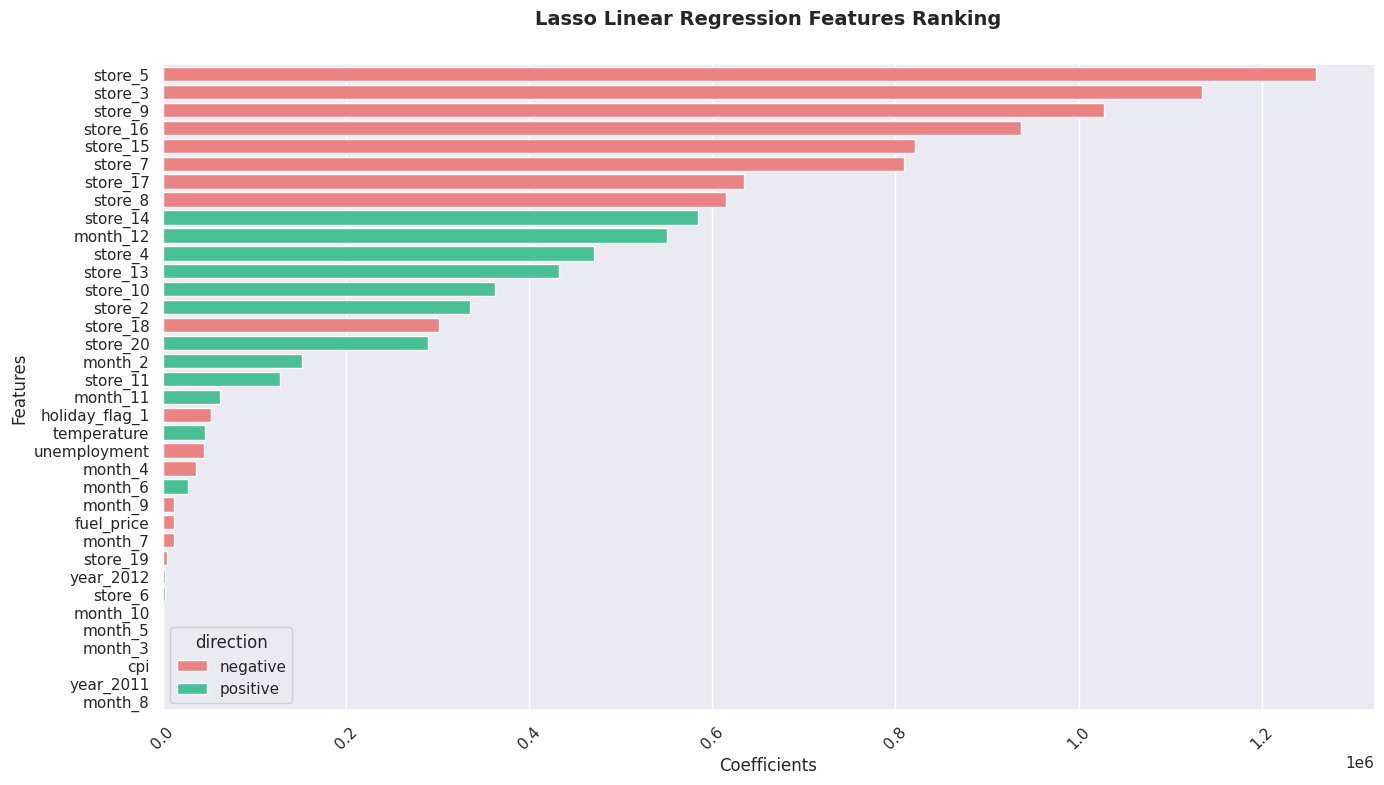

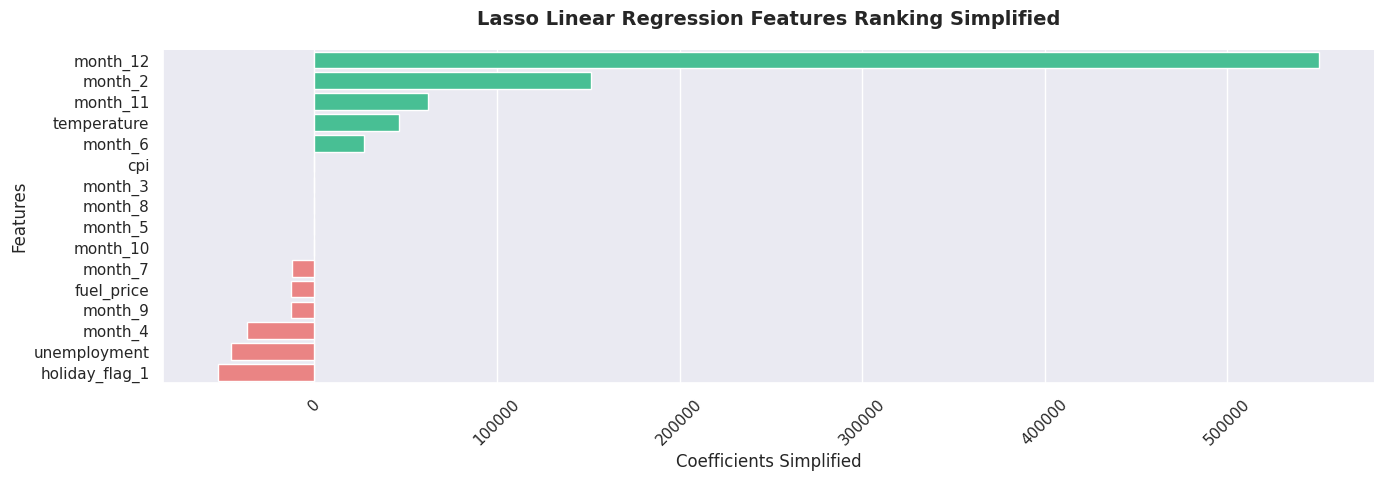

In [21]:
# -----------------------------------------------------------------------------
# LASSO FEATURES IMPORTANCE
# -----------------------------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

coef_lasso_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_model.coef_
}).sort_values('coefficient', ascending=False)

# For readability
coef_lasso_df['feature'] = coef_lasso_df['feature'].str.replace('cat__', '').str.replace('num__', '')
coef_lasso_df['direction'] = coef_lasso_df['coefficient'].map(lambda x: 'positive' if x >= 0 else 'negative')
coef_lasso_simplified_df = coef_lasso_df.copy() # For simplified version
coef_lasso_df['coefficient'] = coef_lasso_df['coefficient'].abs()

coef_lasso_df = coef_lasso_df.sort_values('coefficient', ascending=False).reset_index(drop=True)

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=coef_lasso_df, 
            x='coefficient',
            y='feature',
            hue='direction',
            palette=direction_dict, 
            alpha=1,
)

plt.title(f'Lasso Linear Regression Features Ranking', fontsize=14, fontweight='bold', y=1.05)
plt.ylabel('Features')
plt.xlabel('Coefficients')
plt.xticks(rotation=45)

sns.despine()       # Remove borders for cleaner look
plt.tight_layout()  # Adjust spacing
plt.show()



# -----------------------------------------------------------------------------
# LASSO FEATURES IMPORTANCE SIMPLIFIED
# -----------------------------------------------------------------------------
coef_lasso_simplified_df = coef_lasso_simplified_df[coef_lasso_simplified_df['feature'].isin(feature_list)]

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=coef_lasso_simplified_df, 
            x='coefficient',
            y='feature',
            hue='direction',
            palette=direction_dict, 
            alpha=1,
)

plt.title(f'Lasso Linear Regression Features Ranking Simplified', fontsize=14, fontweight='bold', y=1.05)
plt.ylabel('Features')
plt.xlabel('Coefficients Simplified')
plt.xticks(rotation=45)
ax.get_legend().remove() # type: ignore 

sns.despine()       # Remove borders for cleaner look
plt.tight_layout()  # Adjust spacing
plt.show()

In [22]:
# -----------------------------------------------------------------------------
# COEFFICIENTS REMOVED BY LASSO MODELE
# -----------------------------------------------------------------------------
zeroed_coef = (best_model.coef_ == 0).sum()
print(f'{zeroed_coef} of {len(feature_names)} features zeroed out by Lasso:')

zeroed_features = coef_lasso_df.loc[coef_lasso_df['coefficient'] == 0, 'feature']
print(zeroed_features.tolist())

6 of 36 features zeroed out by Lasso:
['month_10', 'month_5', 'month_3', 'cpi', 'year_2011', 'month_8']


# 5 - Regularized linear regression model: Ridge

## 5.1 - Ridge

In [23]:
# -----------------------------------------------------------------------------
# RIDGE LINEAR REGRESSION
# -----------------------------------------------------------------------------

# Perform grid search
print("Grid search...")
model = Ridge()
# Grid of values to be tested
params = {
    'alpha': [0.001, 0.01, 0.07, 0.077, 0.078, 0.079, 0.08, 0.1, 0.2, 0.5, 1.0, 10.0, 100.0, 1000.0], # 0 corresponds to no regularization
    'fit_intercept': [True, False],
}
gridsearch = GridSearchCV(model, param_grid = params, cv = 5) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best R2 score : ", gridsearch.best_score_)
best_model = gridsearch.best_estimator_


# Predictions
Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

result_ridge = ml_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred, 'Ridge LR')

Grid search...
...Done.
Best hyperparameters :  {'alpha': 0.079, 'fit_intercept': True}
Best R2 score :  0.8976294145235393


## 5.2 - Features importance

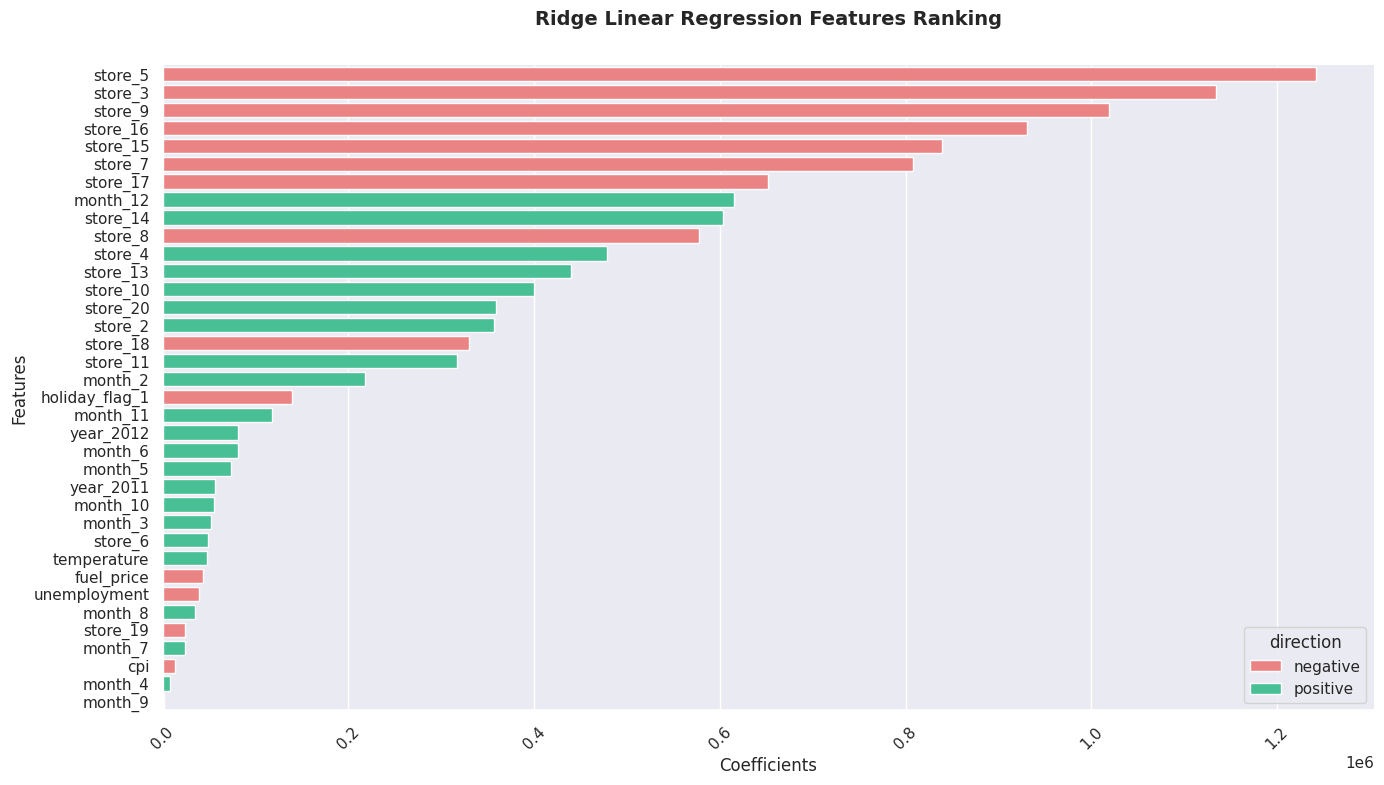

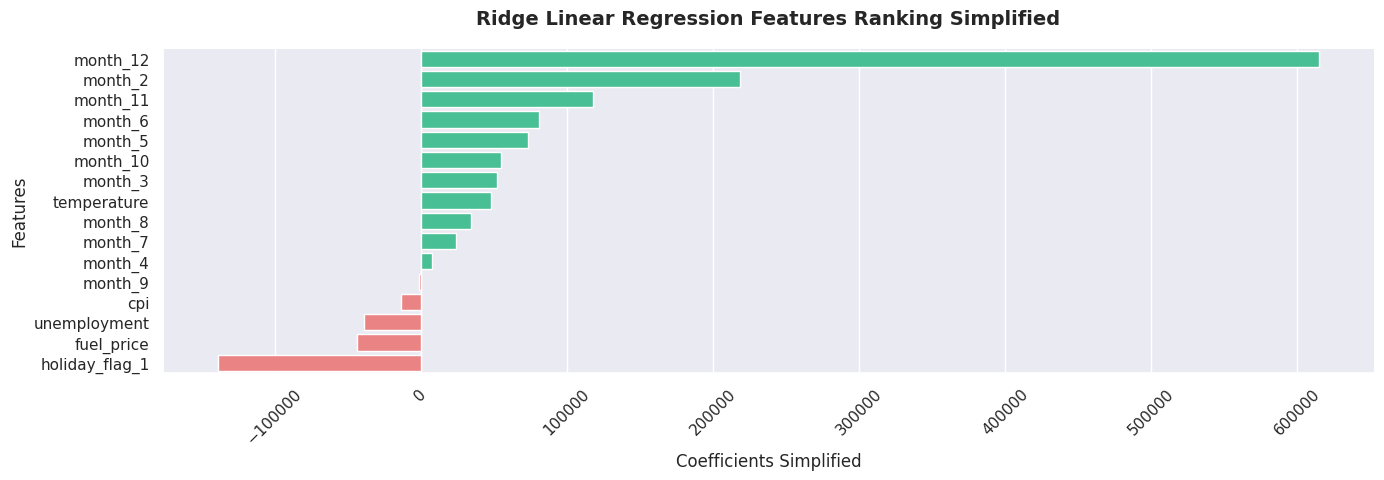

In [24]:
# -----------------------------------------------------------------------------
# RIDGE FEATURES IMPORTANCE
# -----------------------------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

coef_ridge_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_model.coef_
}).sort_values('coefficient', ascending=False)

# For readability
coef_ridge_df['feature'] = coef_ridge_df['feature'].str.replace('cat__', '').str.replace('num__', '')
coef_ridge_df['direction'] = coef_ridge_df['coefficient'].map(lambda x: 'positive' if x >= 0 else 'negative')
coef_ridge_simplified_df = coef_ridge_df.copy() # For simplified version
coef_ridge_df['coefficient'] = coef_ridge_df['coefficient'].abs()

coef_ridge_df = coef_ridge_df.sort_values('coefficient', ascending=False).reset_index(drop=True)

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=coef_ridge_df, 
            x='coefficient',
            y='feature',
            hue='direction',
            palette=direction_dict, 
            alpha=1,
)

plt.title(f'Ridge Linear Regression Features Ranking', fontsize=14, fontweight='bold', y=1.05)
plt.ylabel('Features')
plt.xlabel('Coefficients')
plt.xticks(rotation=45)

sns.despine()       # Remove borders for cleaner look
plt.tight_layout()  # Adjust spacing
plt.show()





# -----------------------------------------------------------------------------
# RIDGE FEATURES IMPORTANCE SIMPLIFIED
# -----------------------------------------------------------------------------
coef_ridge_simplified_df = coef_ridge_simplified_df[coef_ridge_simplified_df['feature'].isin(feature_list)]

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=coef_ridge_simplified_df, 
            x='coefficient',
            y='feature',
            hue='direction',
            palette=direction_dict, 
            alpha=1,
)

plt.title(f'Ridge Linear Regression Features Ranking Simplified', fontsize=14, fontweight='bold', y=1.05)
plt.ylabel('Features')
plt.xlabel('Coefficients Simplified')
plt.xticks(rotation=45)
ax.get_legend().remove() # type: ignore 

sns.despine()       # Remove borders for cleaner look
plt.tight_layout()  # Adjust spacing
plt.show()

# 6 - Overall results

In [25]:
# -----------------------------------------------------------------------------
# MERGING RESULTS
# -----------------------------------------------------------------------------
result = pd.concat([result_lr, result_lasso, result_ridge])
display(result)

,model,set,R2,MAE,RMSE
0,LR,train,0.985434,60351.257614,80315.320260
1,LR,test,0.968564,107248.804640,122316.421053
0,Lasso LR,train,0.981009,67389.107185,91708.561500
1,Lasso LR,test,0.981704,76137.578362,93315.478107
0,Ridge LR,train,0.983639,63160.741632,85122.366514
1,Ridge LR,test,0.977148,89159.041845,104287.236653


Linear regression shows signs of overfitting: training `R² = 0.985` drops to test `R² = 0.969`, a gap of 0.017. The test MAE `~$107k` is ~78% higher than training MAE `~$60k`.

Ridge (`alpha = 0.079`) performs better than plain linear regression, with test `R² = 0.977` vs `0.969` and test `MAE ~$89k` vs `~$107k`, a **~17% reduction**. The train-test gap is also smaller (`0.006` vs `0.017`): L2 regularization is doing corrections.

Lasso (`alpha = 1290`) generalizes better than both models. It achieves the best test on R² `0.982` (vs `0.969` for LR). Test R² (`0.982`) is essentially identical to train R² (`0.981`): this shows no evidence of overfitting.
On test, lasso's MAE is `~$76k`, a **~29% reduction** compared to LR's `~$107k`. Test `RMSE` drops from `~$122k` (LR) to `~$93k`. It also zeroed out 6 of 36 features, producing a simpler, more interpretable model.

Overall, **Lasso is the recommended model**: it offers the best test-set performance across all three metrics (R², MAE, RMSE), no train-test gap, and a simpler feature set.

These comparisons are made on a very small test set (`23 rows` out of `113 usable rows` total), so the ranking should be read as directionally reliable and can't be taken as a statistical truth.